# XGBoost — Walmart Store Sales Forecasting

Model experiment notebook for the XGBoost branch of the multi-model comparison
(LightGBM, XGBoost, deep learning, classical stats). Feature engineering lives
in `utils/feature_engineering.py` and is shared across model notebooks — the
data loading, local train/test split, and walk-forward CV fold boundaries
below are identical to `model_experiment_LightGBM.ipynb` (they're properties
of the data, not the model), so the same leakage/coverage checks already
validated there apply here too.

Executed end-to-end against `xgboost==3.3.0` (added to
`requirements.txt`). The API details flagged during writing checked out on
this version: `early_stopping_rounds`/`eval_metric` as constructor params,
`best_iteration` (no trailing underscore), and `sample_weight_eval_set` taking
a list of per-eval-set weight arrays all work as written.

## Table of Contents
1. [Setup](#1)
2. [Local train/test split](#2)
3. [Walk-forward CV](#3)
4. [Feature selection](#4)
5. [Hyperparameter tuning](#5)
6. [MLflow logging](#6)
7. [Plots](#7)
8. [Full pipeline](#8)

<a id='1'></a>
## 1. Setup

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=DeprecationWarning)

from utils.feature_engineering import build_features, HOLIDAY_DATES
from utils.metrics import wmae

pd.set_option('display.max_columns', 50)

DATA_DIR = 'data/raw/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'test.csv', parse_dates=['Date'])
features = pd.read_csv(DATA_DIR + 'features.csv', parse_dates=['Date'])
stores = pd.read_csv(DATA_DIR + 'stores.csv')

train = train.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(f'train : {train.shape}, {train.Date.min().date()} -> {train.Date.max().date()}')
print(f'test  : {test.shape}, {test.Date.min().date()} -> {test.Date.max().date()}')


train : (421570, 5), 2010-02-05 -> 2012-10-26
test  : (115064, 4), 2012-11-02 -> 2013-07-26


<a id='2'></a>
## 2. Local Train/Test Split

Identical to the LightGBM notebook: last 52 weeks of `train.csv` held out
locally (Kaggle's `test.csv` has no target, so this stands in for it during
development). 52 weeks, not 26, so the holdout covers one of each named
holiday (Thanksgiving/Christmas/Super Bowl/Labor Day) rather than none — see
the LightGBM notebook's Step 2 for the full reasoning.

In [2]:
unique_dates = np.sort(train['Date'].unique())
cutoff_date = unique_dates[-52]

local_train_raw = train[train['Date'] < cutoff_date].copy()
local_test_raw = train[train['Date'] >= cutoff_date].copy()

print(f'cutoff date (first date held out): {pd.Timestamp(cutoff_date).date()}')
print(f'local_train_raw: {local_train_raw.shape}, {local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}  ({local_train_raw.Date.nunique()} weeks)')
print(f'local_test_raw : {local_test_raw.shape}, {local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}  ({local_test_raw.Date.nunique()} weeks)')


cutoff date (first date held out): 2011-11-04
local_train_raw: (267184, 5), 2010-02-05 -> 2011-10-28  (91 weeks)
local_test_raw : (154386, 5), 2011-11-04 -> 2012-10-26  (52 weeks)


In [3]:
def holidays_in_range(dates_series):
    dates_set = set(pd.to_datetime(dates_series))
    present = {}
    for name, dates in HOLIDAY_DATES.items():
        matched = [d for d in pd.to_datetime(dates) if d in dates_set]
        if matched:
            present[name] = [d.date() for d in matched]
    return present


print('local_train_raw holidays:', holidays_in_range(local_train_raw['Date']))
print('local_test_raw  holidays:', holidays_in_range(local_test_raw['Date']))
print()
print('Kaggle test.csv holidays (reference, no target):', holidays_in_range(test['Date']))


local_train_raw holidays: {'SuperBowl': [datetime.date(2010, 2, 12), datetime.date(2011, 2, 11)], 'LaborDay': [datetime.date(2010, 9, 10), datetime.date(2011, 9, 9)], 'Thanksgiving': [datetime.date(2010, 11, 26)], 'Christmas': [datetime.date(2010, 12, 31)]}
local_test_raw  holidays: {'SuperBowl': [datetime.date(2012, 2, 10)], 'LaborDay': [datetime.date(2012, 9, 7)], 'Thanksgiving': [datetime.date(2011, 11, 25)], 'Christmas': [datetime.date(2011, 12, 30)]}



Kaggle test.csv holidays (reference, no target): {'SuperBowl': [datetime.date(2013, 2, 8)], 'Thanksgiving': [datetime.date(2012, 11, 23)], 'Christmas': [datetime.date(2012, 12, 28)]}


<a id='3'></a>
## 3. Walk-Forward Cross-Validation

Same 3 expanding-window folds as the LightGBM notebook (52-week initial
train, 13-week validation windows, walking forward) — fold boundaries are a
property of the data/CV design, not the model, so they're unchanged:

| Fold | Train range | Val range (13 wks) | Val holidays |
|---|---|---|---|
| 1 | 2010-02-05 -> 2011-01-28 (52 wks) | 2011-02-04 -> 2011-04-29 | Super Bowl |
| 2 | 2010-02-05 -> 2011-04-29 (65 wks) | 2011-05-06 -> 2011-07-29 | none |
| 3 | 2010-02-05 -> 2011-07-29 (78 wks) | 2011-08-05 -> 2011-10-28 | Labor Day |

Each fold's validation features are still built with `history_df=<that fold's
train slice>`, enforced by `build_features`'s leakage guard — identical
mechanics to the LightGBM notebook, just a different model consuming the
result.

In [4]:
INITIAL_TRAIN_WEEKS = 52
VAL_WEEKS = 13
N_FOLDS = 3


def make_walk_forward_folds(dates, initial_train_weeks, val_weeks, n_folds):
    folds = []
    for i in range(n_folds):
        train_end_idx = initial_train_weeks + i * val_weeks
        val_end_idx = train_end_idx + val_weeks
        folds.append((dates[:train_end_idx], dates[train_end_idx:val_end_idx]))
    return folds


local_train_dates = np.sort(local_train_raw['Date'].unique())
cv_folds = make_walk_forward_folds(local_train_dates, INITIAL_TRAIN_WEEKS, VAL_WEEKS, N_FOLDS)

for i, (tr_dates, va_dates) in enumerate(cv_folds, start=1):
    print(f'Fold {i}: train {pd.Timestamp(tr_dates[0]).date()} -> {pd.Timestamp(tr_dates[-1]).date()} '
          f'({len(tr_dates)} wks) | val {pd.Timestamp(va_dates[0]).date()} -> {pd.Timestamp(va_dates[-1]).date()} '
          f'({len(va_dates)} wks)')

Fold 1: train 2010-02-05 -> 2011-01-28 (52 wks) | val 2011-02-04 -> 2011-04-29 (13 wks)
Fold 2: train 2010-02-05 -> 2011-04-29 (65 wks) | val 2011-05-06 -> 2011-07-29 (13 wks)
Fold 3: train 2010-02-05 -> 2011-07-29 (78 wks) | val 2011-08-05 -> 2011-10-28 (13 wks)


In [5]:
DROP_COLS = ['Date', 'Weekly_Sales']
CAT_COLS = ['Store', 'Dept', 'Type']


def make_xy(df):
    X = df.drop(columns=DROP_COLS)
    bool_cols = X.select_dtypes(include='bool').columns
    X[bool_cols] = X[bool_cols].astype(int)
    y = df['Weekly_Sales']
    return X, y


Baseline XGBoost (untuned defaults — hyperparameter tuning is Step 5) run
through the walk-forward harness. `enable_categorical=True` + `tree_method='hist'`
lets XGBoost consume the `Store`/`Dept`/`Type` category-dtype columns natively,
mirroring how LightGBM handles them — no one-hot/label encoding needed.

In [6]:
from xgboost import XGBRegressor

baseline_params = dict(n_estimators=300, learning_rate=0.05, random_state=42,
                        enable_categorical=True, tree_method='hist', verbosity=0)

fold_results = []
for i, (tr_dates, va_dates) in enumerate(cv_folds, start=1):
    fold_train_raw = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
    fold_val_raw = local_train_raw[local_train_raw['Date'].isin(va_dates)]
    assert fold_train_raw['Date'].max() < fold_val_raw['Date'].min(), 'fold boundary overlap'

    feat_train = build_features(fold_train_raw, features, stores, history_df=None, is_train=True)
    feat_val = build_features(fold_val_raw, features, stores, history_df=fold_train_raw, is_train=True)

    X_tr, y_tr = make_xy(feat_train)
    X_va, y_va = make_xy(feat_val)

    model = XGBRegressor(**baseline_params)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_va)

    fold_wmae = wmae(y_va, preds, feat_val['IsHoliday'])
    fold_results.append({
        'fold': i,
        'train_start': tr_dates[0], 'train_end': tr_dates[-1],
        'val_start': va_dates[0], 'val_end': va_dates[-1],
        'n_train': len(X_tr), 'n_val': len(X_va),
        'wmae': fold_wmae,
    })
    print(f'Fold {i}: WMAE = {fold_wmae:.2f}  (train n={len(X_tr)}, val n={len(X_va)})')

cv_results_df = pd.DataFrame(fold_results)
cv_results_df


Fold 1: WMAE = 2005.41  (train n=152374, val n=38300)


Fold 2: WMAE = 1739.93  (train n=190674, val n=38164)


Fold 3: WMAE = 1467.53  (train n=228838, val n=38346)


,fold,train_start,train_end,val_start,val_end,n_train,n_val,wmae
0,1,2010-02-05,2011-01-28,2011-02-04,2011-04-29,152374,38300,2005.410718
1,2,2010-02-05,2011-04-29,2011-05-06,2011-07-29,190674,38164,1739.933218
2,3,2010-02-05,2011-07-29,2011-08-05,2011-10-28,228838,38346,1467.526255


In [7]:
print(f'Mean WMAE across folds: {cv_results_df["wmae"].mean():.2f}')
print(f'Std WMAE across folds:  {cv_results_df["wmae"].std():.2f}')


Mean WMAE across folds: 1737.62
Std WMAE across folds:  268.95


<a id='4'></a>
## 4. Feature Selection

Baseline XGBoost fit on the full `local_train_raw` (all 91 weeks) to rank
features by gain-based importance, then drop the zero/near-zero-importance
ones — same procedure as the LightGBM notebook, `importance_type='gain'` set
at construction so `.feature_importances_` reports gain directly.

In [8]:
feat_local_train_full = build_features(local_train_raw, features, stores, history_df=None, is_train=True)
X_full, y_full = make_xy(feat_local_train_full)

importance_model = XGBRegressor(**baseline_params, importance_type='gain')
importance_model.fit(X_full, y_full)

importance_df = pd.DataFrame({
    'feature': X_full.columns,
    'gain': importance_model.feature_importances_,
}).sort_values('gain', ascending=False).reset_index(drop=True)

importance_df


,feature,gain
0,roll_mean_4,0.851900
1,IsThanksgiving,0.019874
2,Dept,0.018110
3,Store,0.014070
4,Year,0.013348
5,WeekOfYear,0.012181
6,IsHoliday,0.010604
7,lag13,0.010263
8,Month,0.009983
9,roll_std_4,0.009877


In [9]:
TOP_N = 20

zero_importance = importance_df.loc[importance_df['gain'] == 0, 'feature'].tolist()
nonzero_df = importance_df[importance_df['gain'] > 0].reset_index(drop=True)

selected_features = nonzero_df['feature'].head(TOP_N).tolist()
dropped_for_rank = nonzero_df['feature'].iloc[TOP_N:].tolist()
dropped_features = zero_importance + dropped_for_rank

print(f'Total candidate features: {len(importance_df)}')
print(f'Zero-importance (dropped): {len(zero_importance)} -> {zero_importance}')
print(f'Nonzero but outside top-{TOP_N} (dropped): {len(dropped_for_rank)} -> {dropped_for_rank}')
print(f'Selected (top-{TOP_N} by gain): {len(selected_features)}')
print(selected_features)


Total candidate features: 28
Zero-importance (dropped): 7 -> ['Type', 'MarkDown4', 'MarkDown3', 'MarkDown1', 'MarkDown5', 'MarkDown2', 'IsChristmas']
Nonzero but outside top-20 (dropped): 1 -> ['IsLaborDay']
Selected (top-20 by gain): 20
['roll_mean_4', 'IsThanksgiving', 'Dept', 'Store', 'Year', 'WeekOfYear', 'IsHoliday', 'lag13', 'Month', 'roll_std_4', 'lag52', 'roll_mean_8', 'Unemployment', 'Temperature', 'roll_std_8', 'DayOfYear', 'Fuel_Price', 'IsSuperBowl', 'Size', 'CPI']


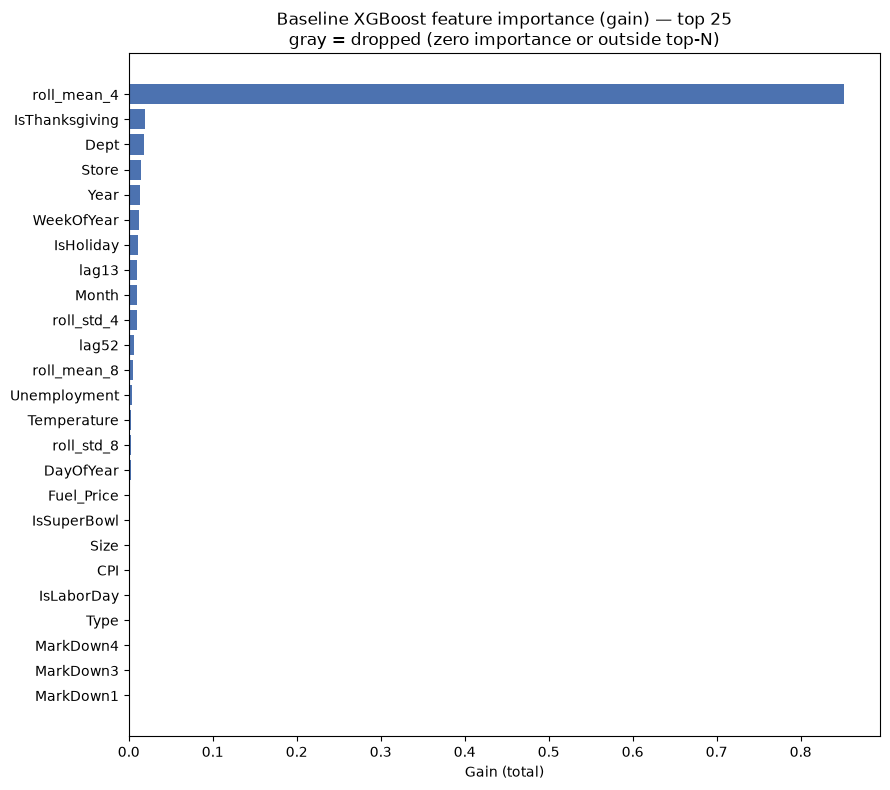

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_df = importance_df.head(25).iloc[::-1]
colors = ['#4C72B0' if f in selected_features else '#B0B0B0' for f in plot_df['feature']]
ax.barh(plot_df['feature'], plot_df['gain'], color=colors)
ax.set_xlabel('Gain (total)')
ax.set_title('Baseline XGBoost feature importance (gain) — top 25\ngray = dropped (zero importance or outside top-N)')
plt.tight_layout()
plt.savefig('plots/feature_importance_baseline_xgb.png', dpi=150)
plt.show()


**Lag-correctness check for the selected lag/rolling features** — identical
verification to the LightGBM notebook (it's testing `build_features`, not the
model), re-run here for completeness rather than assumed from the other
notebook.

In [11]:
lag_features_selected = [f for f in selected_features if f.startswith('lag')]
print('Selected lag features to verify:', lag_features_selected)


def verify_fold_lag_correctness(fold_train_raw, fold_val_raw, feat_val, lag, val_start, sample_size=300, seed=42):
    lag_col = f'lag{lag}'
    sample = feat_val.dropna(subset=[lag_col])
    sample = sample.sample(n=min(sample_size, len(sample)), random_state=seed)
    lookup = fold_train_raw.set_index(['Store', 'Dept', 'Date'])['Weekly_Sales']

    mismatches = 0
    forward_leaks = 0
    for _, row in sample.iterrows():
        source_date = row['Date'] - pd.Timedelta(days=7 * lag)
        if source_date >= val_start:
            forward_leaks += 1
            continue
        expected = lookup.get((row['Store'], row['Dept'], source_date))
        if expected is None or abs(expected - row[lag_col]) > 1e-6:
            mismatches += 1
    return len(sample), mismatches, forward_leaks


all_clear = True
for i, (tr_dates, va_dates) in enumerate(cv_folds, start=1):
    fold_train_raw = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
    fold_val_raw = local_train_raw[local_train_raw['Date'].isin(va_dates)]
    feat_val = build_features(fold_val_raw, features, stores, history_df=fold_train_raw, is_train=True)
    val_start = pd.Timestamp(va_dates[0])

    for lag in [13, 52]:
        if f'lag{lag}' not in lag_features_selected:
            continue
        n, mism, leaks = verify_fold_lag_correctness(fold_train_raw, fold_val_raw, feat_val, lag, val_start)
        status = 'OK' if (mism == 0 and leaks == 0) else 'FAIL'
        if status == 'FAIL':
            all_clear = False
        print(f'Fold {i}, lag{lag}: sampled={n}, mismatches={mism}, forward_leaks={leaks}  [{status}]')

print()
print('ALL CLEAR — selected lag features are leakage-safe across every CV fold.' if all_clear else 'LEAKAGE DETECTED — investigate before proceeding.')


Selected lag features to verify: ['lag13', 'lag52']


Fold 1, lag13: sampled=300, mismatches=0, forward_leaks=0  [OK]
Fold 1, lag52: sampled=300, mismatches=0, forward_leaks=0  [OK]


Fold 2, lag13: sampled=300, mismatches=0, forward_leaks=0  [OK]
Fold 2, lag52: sampled=300, mismatches=0, forward_leaks=0  [OK]


Fold 3, lag13: sampled=300, mismatches=0, forward_leaks=0  [OK]
Fold 3, lag52: sampled=300, mismatches=0, forward_leaks=0  [OK]

ALL CLEAR — selected lag features are leakage-safe across every CV fold.


<a id='5'></a>
## 5. Hyperparameter Tuning (manual grid, WMAE-scored)

Manual grid over 5 XGBoost params, evaluated with the same 3-fold walk-forward
CV harness, restricted to the 20 features selected in Step 4:

| Param | Values | LightGBM analogue |
|---|---|---|
| `max_depth` | 4, 6 | `num_leaves` (different growth strategy — depth-wise vs. leaf-wise) |
| `learning_rate` | 0.05, 0.1 | `learning_rate` |
| `min_child_weight` | 1, 5 | `min_child_samples` (Hessian-sum threshold, not a row count) |
| `subsample` | 0.8, 1.0 | `bagging_fraction` |
| `colsample_bytree` | 0.8, 1.0 | `feature_fraction` |

32 combos x 3 folds = 96 fits, same as the LightGBM grid. `n_estimators` is
capped generously (1000) with early stopping (`early_stopping_rounds=50`)
against each fold's own validation set — set as **constructor** params here
(current XGBoost sklearn API), not passed to `.fit()`. Training and
early-stopping both use holiday-weighted sample weights (5x), matching WMAE
directly, same as the LightGBM notebook.

Verified against the installed `xgboost==3.3.0`: `sample_weight_eval_set`
takes a *list* of weight arrays (one per eval set); `model.best_iteration` (no
trailing underscore, unlike LightGBM's `best_iteration_`); `.predict()`
auto-uses the best iteration when early stopping fired, so the explicit
`iteration_range` below is redundant but left in for explicitness.

In [12]:
def make_fold_matrices(cv_folds, local_train_raw, features, stores, feature_cols):
    fold_data = []
    for tr_dates, va_dates in cv_folds:
        fold_train_raw = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
        fold_val_raw = local_train_raw[local_train_raw['Date'].isin(va_dates)]
        assert fold_train_raw['Date'].max() < fold_val_raw['Date'].min()

        feat_train = build_features(fold_train_raw, features, stores, history_df=None, is_train=True)
        feat_val = build_features(fold_val_raw, features, stores, history_df=fold_train_raw, is_train=True)

        X_tr = feat_train[feature_cols].copy()
        X_va = feat_val[feature_cols].copy()
        for c in X_tr.select_dtypes(include='bool').columns:
            X_tr[c] = X_tr[c].astype(int)
            X_va[c] = X_va[c].astype(int)

        fold_data.append({
            'X_tr': X_tr, 'y_tr': feat_train['Weekly_Sales'],
            'sw_tr': np.where(feat_train['IsHoliday'], 5, 1),
            'X_va': X_va, 'y_va': feat_val['Weekly_Sales'],
            'sw_va': np.where(feat_val['IsHoliday'], 5, 1),
            'is_holiday_va': feat_val['IsHoliday'],
        })
    return fold_data


fold_data = make_fold_matrices(cv_folds, local_train_raw, features, stores, selected_features)
print(f'Precomputed {len(fold_data)} folds, feature set size = {len(selected_features)}')


Precomputed 3 folds, feature set size = 20


In [13]:
import itertools
import time

param_grid = {
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
N_ESTIMATORS_CAP = 1000
EARLY_STOPPING_ROUNDS = 50

param_names = list(param_grid.keys())
param_combos = list(itertools.product(*param_grid.values()))
print(f'{len(param_combos)} hyperparameter combinations x {len(fold_data)} folds = {len(param_combos) * len(fold_data)} fits')


32 hyperparameter combinations x 3 folds = 96 fits


In [14]:
grid_results = []
t_start = time.time()

for combo_idx, combo_values in enumerate(param_combos, start=1):
    params = dict(zip(param_names, combo_values))
    fold_wmaes = []
    fold_best_iters = []

    for fd in fold_data:
        model = XGBRegressor(
            n_estimators=N_ESTIMATORS_CAP,
            enable_categorical=True,
            tree_method='hist',
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            eval_metric='mae',
            random_state=42,
            verbosity=0,
            **params,
        )
        model.fit(
            fd['X_tr'], fd['y_tr'], sample_weight=fd['sw_tr'],
            eval_set=[(fd['X_va'], fd['y_va'])], sample_weight_eval_set=[fd['sw_va']],
            verbose=False,
        )
        preds = model.predict(fd['X_va'], iteration_range=(0, model.best_iteration + 1))
        fold_wmaes.append(wmae(fd['y_va'], preds, fd['is_holiday_va']))
        fold_best_iters.append(model.best_iteration)

    grid_results.append({
        **params,
        'mean_wmae': np.mean(fold_wmaes),
        'std_wmae': np.std(fold_wmaes),
        'fold_wmaes': fold_wmaes,
        'mean_best_iter': np.mean(fold_best_iters),
    })

    elapsed = time.time() - t_start
    print(f'[{combo_idx:2d}/{len(param_combos)}] {params} -> mean_wmae={grid_results[-1]["mean_wmae"]:.2f} '
          f'(elapsed {elapsed:.0f}s)')

print(f'\nGrid search done in {time.time() - t_start:.0f}s')


[ 1/32] {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8} -> mean_wmae=1783.18 (elapsed 17s)


[ 2/32] {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0} -> mean_wmae=1766.88 (elapsed 38s)


[ 3/32] {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 0.8} -> mean_wmae=1774.98 (elapsed 57s)


[ 4/32] {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 1.0} -> mean_wmae=1783.25 (elapsed 73s)


[ 5/32] {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8} -> mean_wmae=1766.06 (elapsed 90s)


...

[28/32] {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 1.0} -> mean_wmae=1678.50 (elapsed 475s)


[29/32] {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8} -> mean_wmae=1678.85 (elapsed 493s)


[30/32] {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 1.0} -> mean_wmae=1679.06 (elapsed 507s)


[31/32] {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 0.8} -> mean_wmae=1673.45 (elapsed 524s)


[32/32] {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 1.0} -> mean_wmae=1683.50 (elapsed 536s)

Grid search done in 536s


In [15]:
grid_results_df = pd.DataFrame(grid_results).sort_values('mean_wmae').reset_index(drop=True)
grid_results_df[['max_depth', 'learning_rate', 'min_child_weight', 'subsample',
                  'colsample_bytree', 'mean_wmae', 'std_wmae', 'mean_best_iter']].head(10)


,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,mean_wmae,std_wmae,mean_best_iter
0,6,0.05,1,0.8,0.8,1646.518695,208.509745,427.666667
1,6,0.05,5,0.8,0.8,1655.371098,208.895737,414.666667
2,6,0.05,1,0.8,1.0,1662.254582,228.421346,409.666667
3,6,0.05,5,0.8,1.0,1664.007246,232.417428,412.000000
4,6,0.10,1,0.8,0.8,1666.950156,225.898946,272.333333
5,6,0.05,1,1.0,0.8,1669.680491,218.125471,367.000000
6,6,0.05,5,1.0,0.8,1673.236013,211.106944,406.333333
7,6,0.10,5,1.0,0.8,1673.451445,228.983505,375.666667
8,6,0.10,1,1.0,1.0,1678.502084,237.324664,371.333333
9,6,0.10,5,0.8,0.8,1678.849594,233.616222,300.666667


In [16]:
best_params = {k: grid_results_df.loc[0, k] for k in param_names}
best_mean_wmae = grid_results_df.loc[0, 'mean_wmae']
best_n_estimators = int(round(grid_results_df.loc[0, 'mean_best_iter'])) + 1

print('Best params:', best_params)
print(f'Best mean CV WMAE: {best_mean_wmae:.2f} (vs baseline untuned mean WMAE: {cv_results_df["wmae"].mean():.2f})')
print(f'Suggested n_estimators for final fit (mean best_iteration across folds + 1): {best_n_estimators}')


Best params: {'max_depth': np.int64(6), 'learning_rate': np.float64(0.05), 'min_child_weight': np.int64(1), 'subsample': np.float64(0.8), 'colsample_bytree': np.float64(0.8)}
Best mean CV WMAE: 1646.52 (vs baseline untuned mean WMAE: 1737.62)
Suggested n_estimators for final fit (mean best_iteration across folds + 1): 429


<a id='6'></a>
## 6. MLflow Logging (DagsHub-hosted)

Same DagsHub-hosted MLflow server as the LightGBM notebook, separate
experiment `XGBoost_Training` so runs from both branches sit side by side but
don't mix. Five runs this time (built complete from the start, rather than
the LightGBM notebook's split-across-two-passes history):

1. `XGBoost_Cleaning` — data shape and local train/test split
2. `XGBoost_Feature_Selection` — baseline importance fit and top-N selection
3. `XGBoost_CV_Tuning` — the 32-combo grid search, batched summary
4. `XGBoost_CV` — refit at tuned params, genuinely incremental per-fold logging
5. `XGBoost_Final_Fit` — the full pipeline (Step 8)

Plot artifacts are skipped (params/metrics only), same choice as the
LightGBM notebook.

In [17]:
import dagshub

dagshub.init(repo_owner='tgela23', repo_name='ml-final-project', mlflow=True)

import mlflow
mlflow.set_experiment('XGBoost_Training')
print('tracking uri:', mlflow.get_tracking_uri())


Accessing as tgela23

Initialized MLflow to track repo "tgela23/ml-final-project"

Repository tgela23/ml-final-project initialized!

tracking uri: https://dagshub.com/tgela23/ml-final-project.mlflow


**Run 1 — `XGBoost_Cleaning`**

In [18]:
with mlflow.start_run(run_name='XGBoost_Cleaning'):
    mlflow.log_param('train_csv_shape', str(train.shape))
    mlflow.log_param('test_csv_shape', str(test.shape))
    mlflow.log_param('train_date_range', f'{train.Date.min().date()} -> {train.Date.max().date()}')

    mlflow.log_param('local_test_holdout_weeks', 52)
    mlflow.log_param('local_train_date_range', f'{local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}')
    mlflow.log_param('local_test_date_range', f'{local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}')

    mlflow.log_metric('n_train_rows', len(train))
    mlflow.log_metric('n_local_train_rows', len(local_train_raw))
    mlflow.log_metric('n_local_test_rows', len(local_test_raw))
    mlflow.log_metric('n_stores', train['Store'].nunique())
    mlflow.log_metric('n_depts', train['Dept'].nunique())

print('XGBoost_Cleaning run logged.')


🏃 View run XGBoost_Cleaning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2/runs/b800645fe2454cfea469de0e947d750c
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2


XGBoost_Cleaning run logged.


**Run 2 — `XGBoost_Feature_Selection`**

In [19]:
with mlflow.start_run(run_name='XGBoost_Feature_Selection'):
    mlflow.log_param('top_n', TOP_N)
    mlflow.log_param('n_candidate_features', len(importance_df))
    mlflow.log_param('n_zero_importance_dropped', len(zero_importance))
    mlflow.log_param('n_rank_dropped', len(dropped_for_rank))
    mlflow.log_param('n_selected', len(selected_features))
    mlflow.log_param('selected_features', ', '.join(selected_features))
    mlflow.log_param('dropped_features', ', '.join(dropped_features))

    for _, row in importance_df.iterrows():
        mlflow.log_metric(f'gain__{row["feature"]}', float(row['gain']))

print('XGBoost_Feature_Selection run logged.')


🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2/runs/43fdd64235b34afb914bd50f048f3553
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2


XGBoost_Feature_Selection run logged.


**Run 3 — `XGBoost_CV_Tuning`**: batched summary of the 32-combo grid search.

In [20]:
with mlflow.start_run(run_name='XGBoost_CV_Tuning'):
    for name, values in param_grid.items():
        mlflow.log_param(f'grid__{name}', values)
    mlflow.log_param('n_estimators_cap', N_ESTIMATORS_CAP)
    mlflow.log_param('early_stopping_rounds', EARLY_STOPPING_ROUNDS)
    mlflow.log_param('n_combos', len(param_combos))
    mlflow.log_param('n_folds', len(fold_data))

    for i, res in enumerate(grid_results, start=1):
        mlflow.log_metric('grid_mean_wmae', res['mean_wmae'], step=i)
        mlflow.log_metric('grid_std_wmae', res['std_wmae'], step=i)

    for k, v in best_params.items():
        mlflow.log_param(f'best_{k}', v)
    mlflow.log_param('best_n_estimators', best_n_estimators)

    mlflow.log_metric('best_mean_wmae', best_mean_wmae)
    mlflow.log_metric('baseline_mean_wmae', cv_results_df['wmae'].mean())
    for i, w in enumerate(grid_results_df.loc[0, 'fold_wmaes'], start=1):
        mlflow.log_metric(f'best_fold{i}_wmae', w)

print('XGBoost_CV_Tuning run logged.')


🏃 View run XGBoost_CV_Tuning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2/runs/55a54b2a53d54dc8b52b874b4b9acac7
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2


XGBoost_CV_Tuning run logged.


**Run 4 — `XGBoost_CV`**: genuinely incremental companion to `XGBoost_CV_Tuning`.
Refits once at the winning hyperparameters across the same 3 folds, no early
stopping this time (`n_estimators` already fixed at the tuned value), and
calls `mlflow.log_metric('fold_wmae', score, step=i)` immediately after each
fold's own fit+predict. Predictions clipped to >=0.

In [21]:
with mlflow.start_run(run_name='XGBoost_CV'):
    XGB_PARAMS = dict(
        objective='reg:squarederror',
        n_estimators=best_n_estimators,
        learning_rate=best_params['learning_rate'],
        max_depth=best_params['max_depth'],
        min_child_weight=best_params['min_child_weight'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        verbosity=0,
    )
    mlflow.log_params(XGB_PARAMS)
    mlflow.log_param('n_cv_splits', len(fold_data))
    mlflow.log_param('n_features', len(selected_features))
    mlflow.log_param('selected_from_hpo', True)

    fold_scores = []
    for i, fd in enumerate(fold_data):
        model = XGBRegressor(**XGB_PARAMS)
        model.fit(fd['X_tr'], fd['y_tr'], sample_weight=fd['sw_tr'])

        preds = np.clip(model.predict(fd['X_va']), 0, None)
        score = wmae(fd['y_va'], preds, fd['is_holiday_va'])
        fold_scores.append(score)

        mlflow.log_metric('fold_wmae', score, step=i)
        print(f'Fold {i}: WMAE = {score:.2f}')

    cv_mean = float(np.mean(fold_scores))
    cv_std = float(np.std(fold_scores))
    mlflow.log_metric('cv_wmae_mean', cv_mean)
    mlflow.log_metric('cv_wmae_std', cv_std)
    print(f'\nWalk-forward CV WMAE: {cv_mean:.2f} +/- {cv_std:.2f}')

print('XGBoost_CV run logged.')


Fold 0: WMAE = 1879.64


Fold 1: WMAE = 1631.04


Fold 2: WMAE = 1416.93



Walk-forward CV WMAE: 1642.54 +/- 189.08


🏃 View run XGBoost_CV at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2/runs/1fdcfc4f25584dbd9420a7e928c47cc0
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2


XGBoost_CV run logged.


<a id='7'></a>
## 7. Plots

Fit once at the tuned hyperparameters on all of `local_train_raw` (91 weeks —
reusing `feat_local_train_full` from Step 4), predict on `local_test_raw`
(the 52-week local holdout, untouched by CV/tuning). All plots saved to
`plots/` with an `_xgb` suffix so they don't collide with the LightGBM
notebook's identically-named files.

In [22]:
feat_local_test = build_features(local_test_raw, features, stores, history_df=local_train_raw, is_train=True)

X_holdout_tr = feat_local_train_full[selected_features].copy()
X_holdout_va = feat_local_test[selected_features].copy()
for c in X_holdout_tr.select_dtypes(include='bool').columns:
    X_holdout_tr[c] = X_holdout_tr[c].astype(int)
    X_holdout_va[c] = X_holdout_va[c].astype(int)
y_holdout_tr = feat_local_train_full['Weekly_Sales']
y_holdout_va = feat_local_test['Weekly_Sales']
sw_holdout_tr = np.where(feat_local_train_full['IsHoliday'], 5, 1)

FINAL_PARAMS = dict(
    objective='reg:squarederror',
    n_estimators=best_n_estimators,
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    verbosity=0,
)

holdout_model = XGBRegressor(**FINAL_PARAMS)
holdout_model.fit(X_holdout_tr, y_holdout_tr, sample_weight=sw_holdout_tr)

holdout_preds = np.clip(holdout_model.predict(X_holdout_va), 0, None)
holdout_wmae = wmae(y_holdout_va, holdout_preds, feat_local_test['IsHoliday'])
print(f'Local-test holdout WMAE (tuned model, 52 weeks, never seen during CV/tuning): {holdout_wmae:.2f}')

feat_local_test = feat_local_test.assign(Predicted=holdout_preds, Residual=y_holdout_va.values - holdout_preds)


Local-test holdout WMAE (tuned model, 52 weeks, never seen during CV/tuning): 1639.12


**Plot 1 — Actual vs. predicted over time**

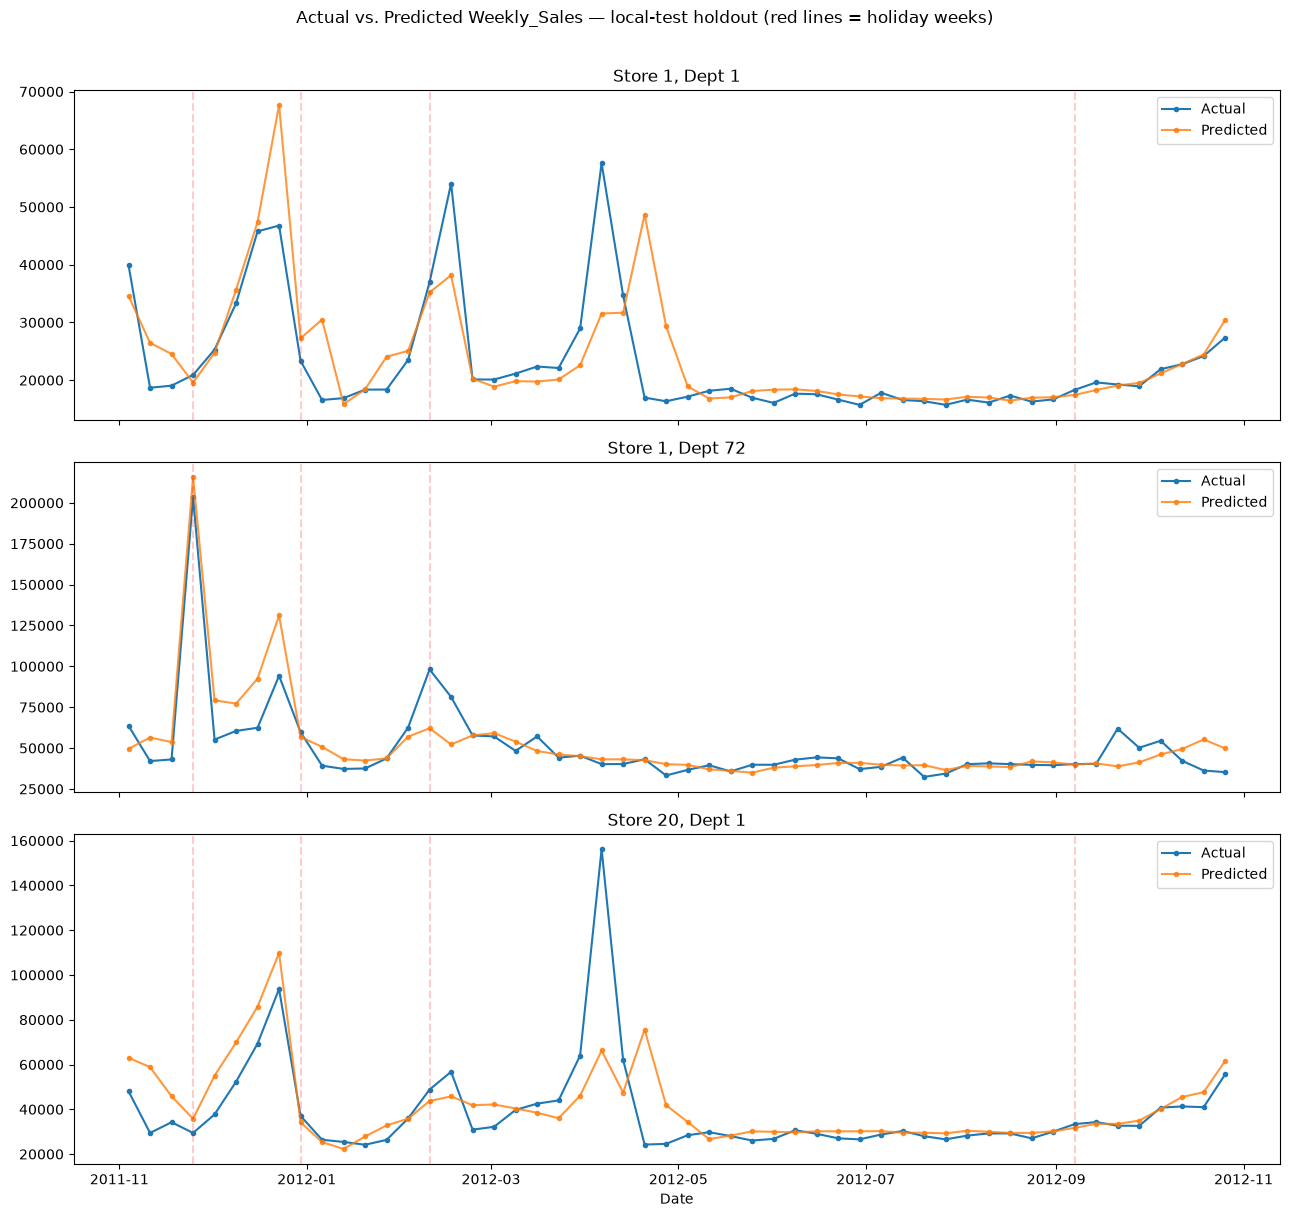

In [23]:
sample_combos = [(1, 1), (1, 72), (20, 1)]
holiday_dates_holdout = feat_local_test.loc[feat_local_test['IsHoliday'], 'Date'].unique()

fig, axes = plt.subplots(len(sample_combos), 1, figsize=(13, 4 * len(sample_combos)), sharex=True)
for ax, (store_id, dept_id) in zip(axes, sample_combos):
    s = feat_local_test[(feat_local_test.Store == store_id) & (feat_local_test.Dept == dept_id)].sort_values('Date')
    ax.plot(s['Date'], s['Weekly_Sales'], label='Actual', marker='o', markersize=3)
    ax.plot(s['Date'], s['Predicted'], label='Predicted', marker='o', markersize=3, alpha=0.8)
    for hd in holiday_dates_holdout:
        ax.axvline(pd.Timestamp(hd), color='red', alpha=0.2, linestyle='--')
    ax.set_title(f'Store {store_id}, Dept {dept_id}')
    ax.legend()
axes[-1].set_xlabel('Date')
plt.suptitle('Actual vs. Predicted Weekly_Sales — local-test holdout (red lines = holiday weeks)', y=1.01)
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_timeseries_xgb.png', dpi=150, bbox_inches='tight')
plt.show()


**Plot 2 — Feature importance** of the tuned model (gain).

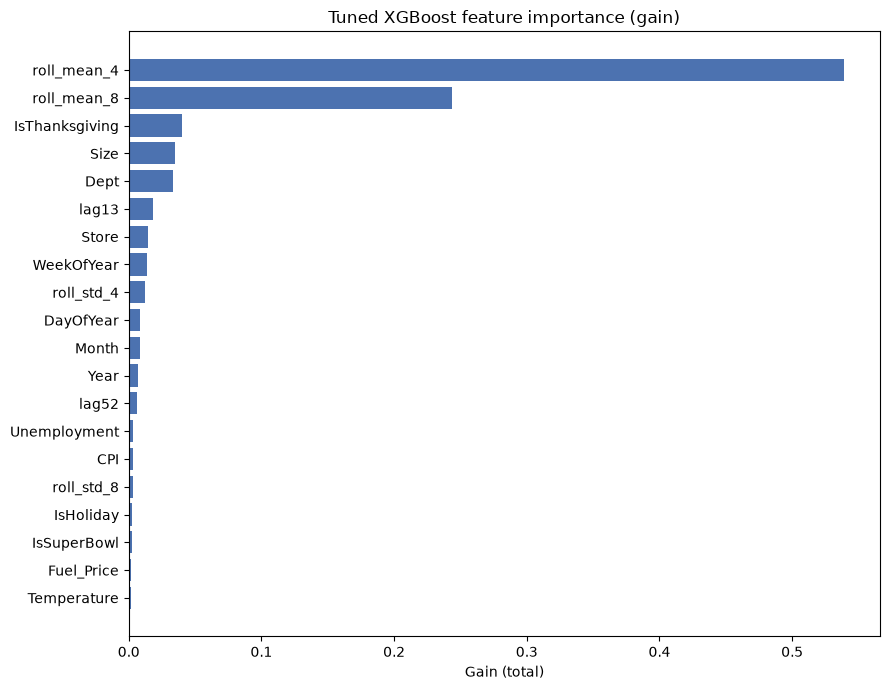

In [24]:
tuned_importance_df = pd.DataFrame({
    'feature': X_holdout_tr.columns,
    'gain': holdout_model.feature_importances_,
}).sort_values('gain', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
plot_df = tuned_importance_df.iloc[::-1]
ax.barh(plot_df['feature'], plot_df['gain'], color='#4C72B0')
ax.set_xlabel('Gain (total)')
ax.set_title('Tuned XGBoost feature importance (gain)')
plt.tight_layout()
plt.savefig('plots/feature_importance_tuned_xgb.png', dpi=150)
plt.show()


**Plot 3 — WMAE by fold**, baseline (untuned) vs. tuned.

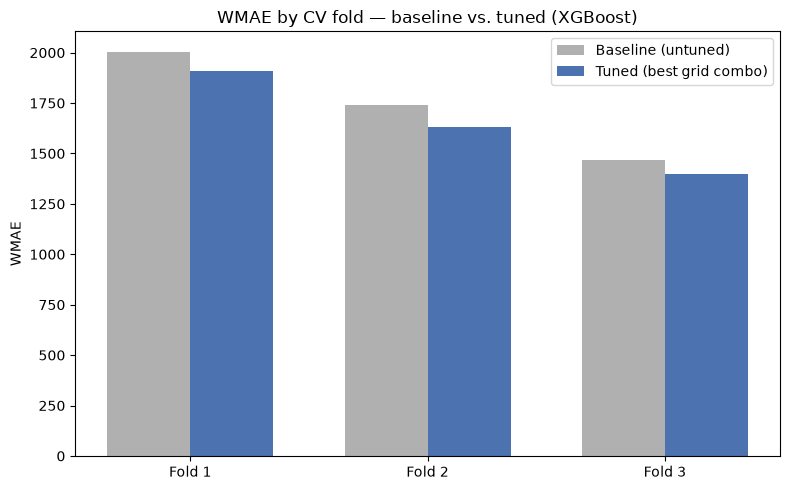

In [25]:
tuned_fold_wmaes = grid_results_df.loc[0, 'fold_wmaes']
baseline_fold_wmaes = cv_results_df['wmae'].tolist()

fold_labels = [f'Fold {i+1}' for i in range(len(baseline_fold_wmaes))]
x = np.arange(len(fold_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, baseline_fold_wmaes, width, label='Baseline (untuned)', color='#B0B0B0')
ax.bar(x + width / 2, tuned_fold_wmaes, width, label='Tuned (best grid combo)', color='#4C72B0')
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylabel('WMAE')
ax.set_title('WMAE by CV fold — baseline vs. tuned (XGBoost)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/wmae_by_fold_xgb.png', dpi=150)
plt.show()


**Plot 4 — Residual distribution**

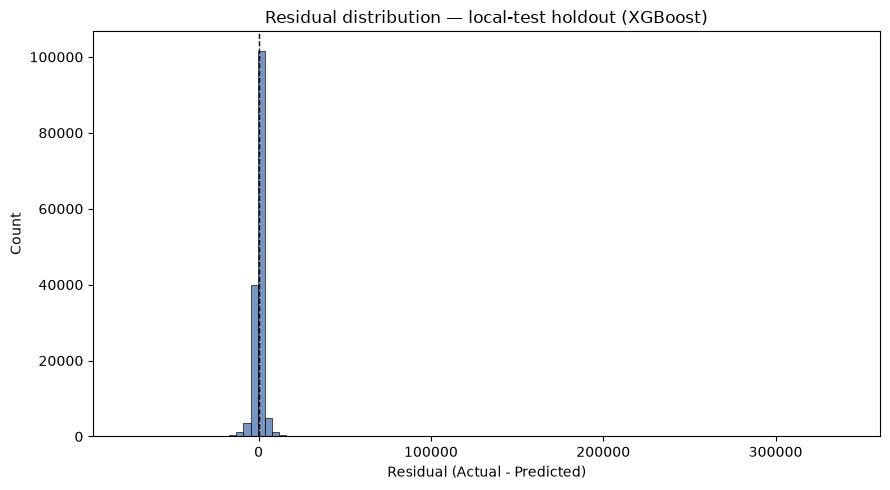

count    154386.000000
mean       -144.339418
std        3594.249844
min      -75253.730625
25%        -726.151461
50%         -51.683027
75%         510.448708
max      339854.273750
Name: Residual, dtype: float64


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(feat_local_test['Residual'], bins=100, ax=ax, color='#4C72B0')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_title('Residual distribution — local-test holdout (XGBoost)')
plt.tight_layout()
plt.savefig('plots/residual_distribution_xgb.png', dpi=150)
plt.show()

print(feat_local_test['Residual'].describe())


**Plot 5 — Actual vs. predicted, holiday vs. non-holiday weeks**

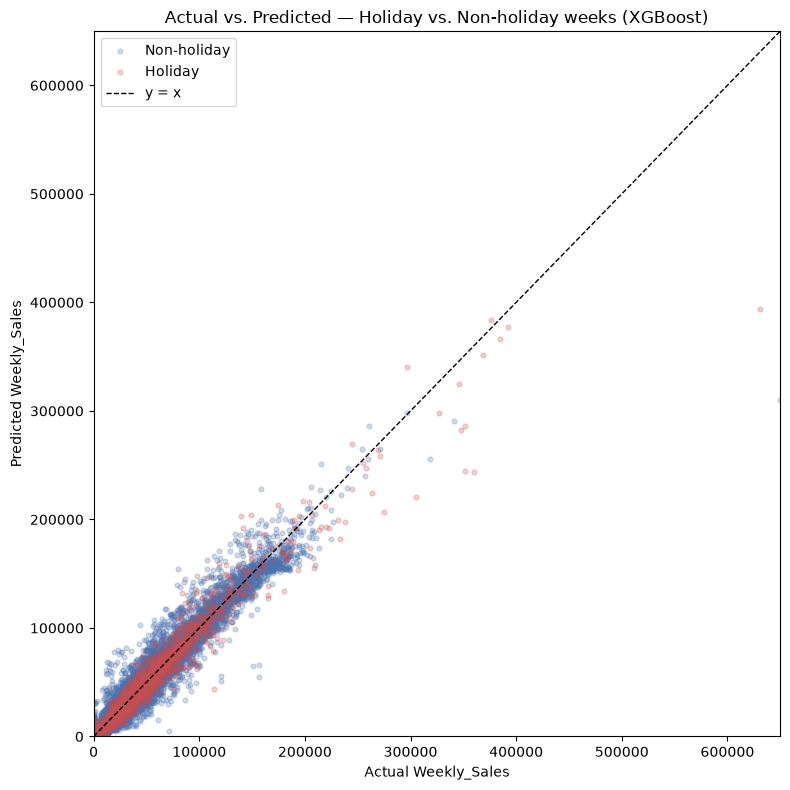

Unweighted MAE by week type:
IsHoliday
False    1498.260899
True     1973.649635
Name: abs_err, dtype: float64


In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
for is_holiday, color, label in [(False, '#4C72B0', 'Non-holiday'), (True, '#C44E52', 'Holiday')]:
    subset = feat_local_test[feat_local_test['IsHoliday'] == is_holiday]
    ax.scatter(subset['Weekly_Sales'], subset['Predicted'], alpha=0.25, s=12, color=color, label=label)
lims = [0, feat_local_test[['Weekly_Sales', 'Predicted']].to_numpy().max()]
ax.plot(lims, lims, color='black', linewidth=1, linestyle='--', label='y = x')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Predicted Weekly_Sales')
ax.set_title('Actual vs. Predicted — Holiday vs. Non-holiday weeks (XGBoost)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_holiday_xgb.png', dpi=150)
plt.show()

mae_by_holiday = feat_local_test.assign(abs_err=feat_local_test['Residual'].abs()).groupby('IsHoliday')['abs_err'].mean()
print('Unweighted MAE by week type:')
print(mae_by_holiday)


<a id='8'></a>
## 8. Full Pipeline (Feature Engineering + Selection + Model)

Same `FeatureEngineeringTransformer`/`FeatureSelector` classes as the
LightGBM notebook — they're model-agnostic (`utils/feature_engineering.py`),
so nothing needed to change there. Only the final estimator differs
(`XGBRegressor` instead of `LGBMRegressor`). Fit on all of `train.csv`.

In [28]:
from sklearn.pipeline import Pipeline
from utils.feature_engineering import FeatureEngineeringTransformer, FeatureSelector

full_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineeringTransformer(features=features, stores=stores)),
    ('feature_selection', FeatureSelector(feature_names=selected_features)),
    ('model', XGBRegressor(**FINAL_PARAMS)),
])

sw_full = np.where(train['IsHoliday'], 5, 1)
full_pipeline.fit(train, train['Weekly_Sales'], model__sample_weight=sw_full)
print('Pipeline fit on all of train.csv:', train.shape)


Pipeline fit on all of train.csv: (421570, 5)


**Confirm it truly takes raw input**: predict on bare rows straight from
`test.csv` — unmerged, un-featurized.

In [29]:
raw_sample = test.head(5)
print('Raw input columns (exactly test.csv, nothing pre-computed):', list(raw_sample.columns))
raw_preds = full_pipeline.predict(raw_sample)
print('Predictions:', raw_preds)


Raw input columns (exactly test.csv, nothing pre-computed): ['Store', 'Dept', 'Date', 'IsHoliday']


Predictions: [36453.01  20558.043 20637.979 19130.213 21333.227]


**Save to MLflow (DagsHub model registry)** inside `XGBoost_Final_Fit`.
`serialization_format='cloudpickle'` — same fix as the LightGBM notebook,
skops doesn't support the custom transformer classes.

In [30]:
from mlflow.models import infer_signature

signature = infer_signature(raw_sample, raw_preds)

with mlflow.start_run(run_name='XGBoost_Final_Fit'):
    mlflow.log_params(FINAL_PARAMS)
    mlflow.log_param('n_features', len(selected_features))
    mlflow.log_param('train_rows', len(train))
    mlflow.log_metric('local_holdout_wmae', holdout_wmae)

    mlflow.sklearn.log_model(
        full_pipeline,
        artifact_path='model',
        signature=signature,
        input_example=raw_sample,
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )

print('XGBoost_Final_Fit run logged, pipeline saved to MLflow model registry.')


/Users/r00t/ml-final-project/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2026/07/23 01:45:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/23 01:45:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_Final_Fit at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2/runs/d7dcd01c91fc45ae8cee62bd950a7464
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/2


XGBoost_Final_Fit run logged, pipeline saved to MLflow model registry.


**Also save locally with `joblib`** under `models/`.

In [31]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(full_pipeline, 'models/xgboost_pipeline.joblib')
print('Saved to models/xgboost_pipeline.joblib')

reloaded = joblib.load('models/xgboost_pipeline.joblib')
reloaded_preds = reloaded.predict(raw_sample)
print('Reloaded-pipeline predictions match:', np.allclose(reloaded_preds, raw_preds))


Saved to models/xgboost_pipeline.joblib


Reloaded-pipeline predictions match: True
